# Edge Orchestrator, Sensitivity, and the Persistence Counterfactual

Runs the deterministic load-control rule over the held-out test split,
sweeps the safe grid-limit parameter, and, in the part that answers "does the
forecaster actually matter to the control loop?", reruns the orchestrator
on persistence forecasts and measures how often its decision disagrees with
XGBoost's (Section VI-C). Also logs every individual throttle event with a
`genuine_risk` flag computed from actual, not forecasted, values, since the
aggregate throttle rate at the default grid limit is too sparse (11/11,537
intervals) to say anything about control quality on its own.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from evloadcontrol.analysis import charger_utilization_stats, hourly_error_breakdown
from evloadcontrol.data import load_extended_raw, load_raw_data
from evloadcontrol.features import build_features, split_data
from evloadcontrol.models import persistence_predictions, train_model
from evloadcontrol.orchestrator import (
    edge_orchestrator,
    grid_limit_sensitivity,
    orchestrator_agreement,
    orchestrator_event_log,
    summarize_orchestration,
)
from evloadcontrol.plotting import plot_grid_sensitivity

DATA_PATH = Path('../data/20260514_uma_adabyron_data.csv')
GRID_LIMIT = 5000.0


In [2]:
raw_frame, charger_ids = load_raw_data(DATA_PATH)
feature_frame = build_features(raw_frame, charger_ids)
x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test = split_data(feature_frame)

model_pv = train_model(x_train, y_pv_train)
model_ev = train_model(x_train, y_ev_train)

pv_predictions = model_pv.predict(x_test)
ev_predictions = model_ev.predict(x_test)
connected_evs = x_test['total_evs_connected'].to_numpy()


## A single decision, then the aggregate rate


In [3]:
test_state = x_test.iloc[0]
decision = edge_orchestrator(
    predicted_pv=float(pv_predictions[0]),
    predicted_ev=float(ev_predictions[0]),
    current_evs_connected=int(round(float(test_state['total_evs_connected']))),
    grid_limit=GRID_LIMIT,
)
decision


{'status': 'stable',
 'message': 'Grid stable. Normal charging operations permitted.',
 'predicted_pv': 47.25394058227539,
 'predicted_ev': 32.806922912597656,
 'current_evs_connected': 0,
 'grid_limit': 5000.0}

In [4]:
orchestration_stats = summarize_orchestration(
    pv_predictions, ev_predictions, connected_evs, grid_limit=GRID_LIMIT,
)
orchestration_stats


{'n_intervals': 11537,
 'n_stable': 11526,
 'n_throttle': 11,
 'n_inspect': 0,
 'throttle_rate': 0.0009534541041865303,
 'mean_reduction_per_ev_w': 786.8160600142045,
 'max_reduction_per_ev_w': 1797.58837890625}

## Individual event log with genuine-risk flags (Section VI-C)

At `GRID_LIMIT`, only ~11 intervals trigger, too few to assess control
quality from the rate alone, so every triggering interval is logged
individually here, plus the same run at a 1 kW stress case for a larger,
higher-precision sample.


In [5]:
event_log_default = orchestrator_event_log(
    pv_predictions, ev_predictions,
    y_pv_test.to_numpy(), y_ev_test.to_numpy(),
    connected_evs, x_test.index, grid_limit=GRID_LIMIT,
)
event_log_1kw = orchestrator_event_log(
    pv_predictions, ev_predictions,
    y_pv_test.to_numpy(), y_ev_test.to_numpy(),
    connected_evs, x_test.index, grid_limit=1000.0,
)
print(
    f"{len(event_log_default)} events at {GRID_LIMIT:.0f} W "
    f"({event_log_default['genuine_risk'].sum()} genuine), "
    f"{len(event_log_1kw)} events at 1000 W "
    f"({event_log_1kw['genuine_risk'].sum()} genuine)"
)
event_log_default


11 events at 5000 W (5 genuine), 69 events at 1000 W (63 genuine)


,timestamp,evs_connected,predicted_pv_w,predicted_ev_w,actual_pv_w,actual_ev_w,deficit_w,reduction_per_ev_w,actual_deficit_w,genuine_risk
0,2026-01-19 07:30:00,1,493.026306,6747.859375,604.384640,5392.590909,1254.833008,1254.833008,0.000000,False
1,2026-01-19 07:45:00,1,1196.691406,6841.799805,1015.230800,5396.309126,645.108398,645.108398,0.000000,False
2,2026-01-20 08:30:00,4,3395.772705,9520.714844,2726.400000,10621.145730,1124.942383,281.235596,2894.745730,True
3,2026-01-20 08:45:00,4,3267.923828,10761.062500,4102.750000,8976.984788,2493.138672,623.284668,0.000000,False
4,2026-01-21 07:15:00,2,319.553802,6645.506348,277.916660,6282.036532,1325.952637,662.976318,1004.119872,True
5,2026-01-21 07:30:00,2,796.639282,7120.208984,750.642900,4921.742833,1323.569824,661.784912,0.000000,False
6,2026-01-23 07:00:00,1,195.585892,6993.174316,0.000000,8214.563743,1797.588379,1797.588379,3214.563743,True
7,2026-01-23 07:15:00,2,466.608124,7536.725586,53.153847,8550.281916,2070.117676,1035.058838,3497.128069,True
8,2026-01-23 07:30:00,3,687.674438,7752.122559,266.714300,6807.591777,2064.448242,688.149414,1540.877477,True
9,2026-01-23 07:45:00,3,756.935547,8033.784668,425.363650,3525.241760,2276.849121,758.949707,0.000000,False


## Does the forecaster matter to the control loop? (persistence counterfactual)

Reruns the same deterministic rule on persistence forecasts instead of
XGBoost's, at the same grid limit, and measures how often the binary
throttle/no-throttle decision actually changes.


In [6]:
persistence_pv, persistence_ev = persistence_predictions(x_test)

persistence_stats = summarize_orchestration(
    persistence_pv, persistence_ev, connected_evs, grid_limit=GRID_LIMIT,
)
agreement = orchestrator_agreement(
    pv_predictions, ev_predictions,
    persistence_pv, persistence_ev,
    connected_evs, grid_limit=GRID_LIMIT,
)
print(f"XGBoost throttles:     {orchestration_stats['n_throttle']}/{orchestration_stats['n_intervals']}")
print(
    f"Persistence throttles: {persistence_stats['n_throttle']}/{persistence_stats['n_intervals']} "
    f"(mean reduction {persistence_stats['mean_reduction_per_ev_w']:.2f} W/EV)"
)
print(f"Decisions agree in {agreement['agreement_rate'] * 100:.2f}% of intervals ({agreement['n_disagreements']} disagreements)")


XGBoost throttles:     11/11537
Persistence throttles: 17/11537 (mean reduction 589.50 W/EV)
Decisions agree in 99.93% of intervals (8 disagreements)


## Grid-limit sensitivity sweep


In [7]:
sensitivity = grid_limit_sensitivity(
    pv_predictions,
    ev_predictions,
    connected_evs,
    grid_limits=[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 10000, 12000],
)
sensitivity


,grid_limit_w,n_intervals,n_stable,n_throttle,n_inspect,throttle_rate,mean_reduction_per_ev_w,max_reduction_per_ev_w
0,1000,11537,11468,69,0,0.005981,954.582699,5797.588379
1,2000,11537,11502,35,0,0.003034,1130.462916,4797.588379
2,3000,11537,11518,19,0,0.001647,1273.658198,3797.588379
3,4000,11537,11524,13,0,0.001127,1138.644908,2797.588379
4,5000,11537,11526,11,0,0.000953,786.816060,1797.588379
5,6000,11537,11527,10,0,0.000867,314.320160,797.588379
6,7000,11537,11533,4,0,0.000347,68.027323,123.284668
7,8000,11537,11537,0,0,0.000000,0.000000,0.000000
8,10000,11537,11537,0,0,0.000000,0.000000,0.000000
9,12000,11537,11537,0,0,0.000000,0.000000,0.000000


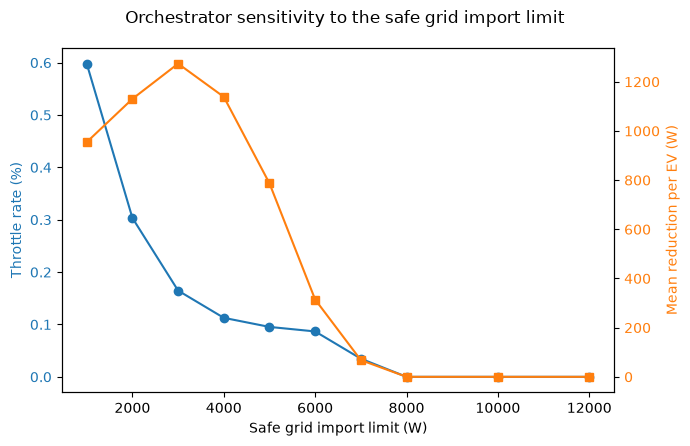

In [8]:
fig = plot_grid_sensitivity(sensitivity)
plt.show()


## Temporal error breakdown and per-charger utilization


In [9]:
hourly_errors = hourly_error_breakdown(
    x_test.index, y_pv_test, pv_predictions, y_ev_test, ev_predictions
)
hourly_errors


,hour_bucket,pv_mae,ev_mae,n,hour_range
0,0,30.676727,4.423144,2880,00-06
1,6,797.199094,172.739491,2897,06-12
2,12,932.627990,73.523883,2880,12-18
3,18,52.933359,8.096967,2880,18-00


In [10]:
extended_frame = load_extended_raw(DATA_PATH, charger_ids)
charger_stats = charger_utilization_stats(extended_frame, charger_ids)
charger_stats


,charger_id,total_energy_delivered_kwh,pct_time_charging
0,1,3708.303,4.744554
1,2,4439.249,5.426296
2,3,5781.947,6.282057
3,4,6733.948,7.266503
4,5,8124.436,8.440123


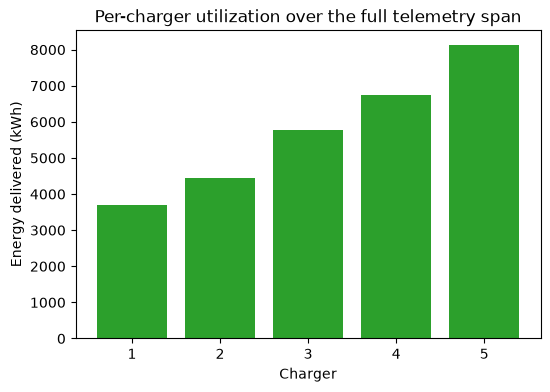

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(charger_stats['charger_id'].astype(str), charger_stats['total_energy_delivered_kwh'], color='tab:green')
ax.set_xlabel('Charger')
ax.set_ylabel('Energy delivered (kWh)')
ax.set_title('Per-charger utilization over the full telemetry span')
plt.show()
